# Tutorial 19 — Iron: orbital magnetization

The waw-native reimagining of Wannier90 tutorial 19 (the postw90 `berry_task = morb` module). Spin-orbit coupling gives ferromagnetic iron a small **orbital** magnetic moment on top of its dominant spin moment -- the intrinsic **orbital magnetization** $M_{\rm orb}$ (Ceresoli-Thonhauser-Vanderbilt-Resta, PRB 74, 024408 (2006); Lopez-Vanderbilt-Souza-Tsirkin, PRB 85, 014435 (2012)).

$M_{\rm orb}$ is a Fermi-surface trace of THREE gauge-invariant quantities, $-2\mathrm{Im}[f]$, $-2\mathrm{Im}[g]$, $-2\mathrm{Im}[h]$ -- $-2\mathrm{Im}[f]$ is exactly the Berry curvature trace notebook 18's anomalous Hall conductivity already uses; $-2\mathrm{Im}[g]/-2\mathrm{Im}[h]$ need two NEW real-space quantities, $BB(R)=\langle 0|H(r-R)|R\rangle$ and $CC(R)=\langle 0|r_\alpha H(r-R)_\beta|R\rangle$ (`core.hamiltonian.compute_bb_r`/`compute_cc_r`). $CC(R)$ needs a genuinely new ab-initio overlap, `pw2wannier90`'s $\langle u_{k+b_1}|H_k|u_{k+b_2}\rangle$ (`write_uHu=.true.`, `interfaces.wannier90.io.read_uHu`) -- $BB(R)$, in contrast, needs only the already-familiar `.mmn` overlap plus the DFT eigenvalues, since $H_k$ acts diagonally on its own eigenstate.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Converged noncollinear+SOC DFT and Wannierisation (+ `.uHu`)
Identical recipe to notebooks 17/18 (same converged noncollinear+SOC Fe, 18 spinor MLWFs from 28 bands, 4x4x4 mesh), with `write_uHu=True` added so `pw2wannier90` also writes the $\langle u_{k+b_1}|H_k|u_{k+b_2}\rangle$ overlap. (The SCF is the slow step if `runs/fe/` isn't already populated by notebooks 17/18 -- a few minutes; `write_uHu` itself adds a modest amount of extra `pw2wannier90` time.)

In [2]:
from ase.build import bulk
import torch
from waw.interfaces.ase.structure import real_lattice, recip_lattice
from waw.core.spread import rotate_overlaps, weight_overlaps_by_eigenvalues
from waw.core.hamiltonian import compute_position_r, compute_bb_r, compute_cc_r
from waw.analysis.orbital_magnetization import orbital_magnetization
from waw.units import EV_TO_HARTREE

atoms = bulk('Fe', 'bcc', a=2.8699)          # 5.4235 bohr
MP_GRID = (4, 4, 4)
WORK = HERE / 'runs' / 'fe'

# noncollinear + spin-orbit; PseudoDojo fully-relativistic Fe pseudo
SOC = dict(noncolin=True, lspinorb=True)
SOC['starting_magnetization(1)'] = 0.4
SOC.update(occupations='smearing', smearing='cold', degauss=0.02)

# Same recipe as notebooks 17/18 (28 -> 18 spinor MLWFs), plus write_uHu=True
# for the extra <u_{k+b1}|H_k|u_{k+b2}> overlap orbital magnetization needs.
ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'fe',
    ecutwfc=60, scf_kpts=(16, 16, 16), nbnd=36, num_wann=18,
    exclude_bands=list(range(1, 9)),
    scdm_entanglement='erfc', scdm_mu=25.0, scdm_sigma=5.0,
    system_extra=SOC, pseudopotentials={'Fe': 'Fe-sp_r.upf'},
    pseudo_dir=PSEUDO_DIR, ncores=NCORES, write_uHu=True,
    rerun_scf=False,          # reuse a completed SCF in runs/fe/ if present
)

result = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'], nw=18,
    outer_window=(8.0, 70.0), frozen_window=(8.0, 19.8),
    n_restarts=2, dis_n_iter=1000, n_iter=3000, verbose=False,
)
E_FERMI = ov['fermi_energy']                 # eV, read from the SCF by qe.py
print(f'Omega_I = {result.dis.omega_i * BOHR_TO_ANG**2:.4f} Ang^2  '
      f'(18 spinor MLWFs from 28 bands); E_F = {E_FERMI:.3f} eV')

REAL = real_lattice(atoms)
RECIP = recip_lattice(atoms)
V, U = result.dis.V, result.spread.U_final
W = torch.bmm(V, U)   # (nk, nb, nw) full converged gauge, for compute_cc_r

Omega_I = 9.3225 Ang^2  (18 spinor MLWFs from 28 bands); E_F = 17.630 eV


### Interpolated bands against the ab-initio reference
The Wannier bands (lines) over a non-self-consistent `calculation='bands'` run
along the same path (points), with the disentanglement windows shaded and
everything referred to $E_F$. Inside the frozen window the interpolation must
reproduce the ab-initio bands exactly; the printed deviation on the
Wannierization mesh itself is the quantitative form of the same statement.

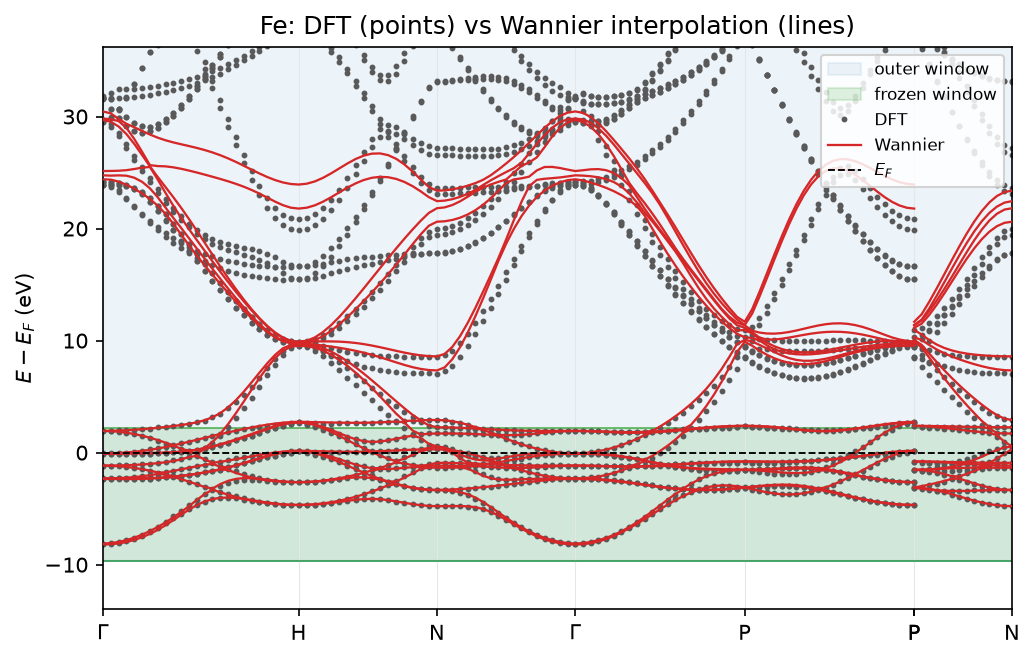

on the Wannier mesh, inside the frozen window: max 0.000 meV, rms 0.000 meV over 629 states


In [3]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = E_FERMI
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(result.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'fe', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=(8.0, 70.0), frozen_window=(8.0, 19.8), fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('Fe: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result.hr, ov['kpts'], ov['eig'],
                    window=(8.0, 19.8), fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


### 2. Building BB(R) and CC(R)
$BB(R)$ comes from the SAME `.mmn` overlaps notebook 18's $AA(R)$ used, but with the bra band index first weighted by its ab-initio eigenvalue (`weight_overlaps_by_eigenvalues`) -- since $H_k|u_{m,k}\rangle = \varepsilon_{m,k}|u_{m,k}\rangle$, this IS $\langle u_{m,k}|H_k$ in the bra of the $(k,k+b)$ overlap, no `.uHu` needed. $CC(R)$ genuinely needs `.uHu`: it connects TWO different neighbours of $k$, $\langle u_{k+b_1}|H_k|u_{k+b_2}\rangle$, which cannot be recovered from `.mmn` + eigenvalues the way $BB(R)$ can.

In [4]:
Mmn_weighted = weight_overlaps_by_eigenvalues(result.wdata.Mmn, result.wdata.eig)
H_opt   = rotate_overlaps(V, Mmn_weighted, result.wdata.kb_idx)
H_tilde = rotate_overlaps(U, H_opt, result.wdata.kb_idx)

AA_R = compute_position_r(result.m_tilde, result.wdata.wb, result.wdata.bvecs,
                          result.wdata.kpts, MP_GRID, REAL)
BB_R = compute_bb_r(H_tilde, result.wdata.wb, result.wdata.bvecs,
                    result.wdata.kpts, MP_GRID, REAL)

uHu = torch.tensor(ov['uHu'], dtype=torch.complex128) * EV_TO_HARTREE   # .uHu is in eV, like .eig
CC_R = compute_cc_r(uHu, W, result.wdata.kb_idx, result.wdata.wb, result.wdata.bvecs,
                    result.wdata.kpts, MP_GRID, REAL)
print('AA_R, BB_R, CC_R built:', AA_R.shape, BB_R.shape, CC_R.shape)

AA_R, BB_R, CC_R built: torch.Size([3, 89, 18, 18]) torch.Size([3, 89, 18, 18]) torch.Size([3, 3, 89, 18, 18])


### 3. Orbital magnetization
$M_{\rm orb}$ is evaluated on a dense interpolation mesh (postw90's `berry_kmesh`) -- a much finer mesh than the 4x4x4 mesh the Wannier model itself was built on, the same dense-mesh-from-a-coarse-DFT-calculation trick notebook 18's AHC already relies on.

**A caveat worth stating plainly**: $M_{\rm orb}$ is a notoriously delicate quantity -- it is built from second-order, SOC-driven cross-differences of an already-small effect, and is far more sensitive to the underlying Wannier-model mesh density than a band structure or even the AHC is. This notebook deliberately reuses notebooks 17/18's fast 4x4x4-mesh model, so the value below should be read as illustrative, not converged. The implementation itself (`analysis.orbital_magnetization`, `compute_bb_r`/`compute_cc_r`, `read_uHu`) was separately validated bit-for-bit against a real, much denser (8x8x8 Wannierisation + 25x25x25 `berry_kmesh`) `wannier90.x`/`postw90.x` reference run of this same Fe system: waw reproduced $\Omega_I$/$\Omega_{\rm total}$ to 5 decimal places and $M_{\rm orb}$'s dominant $z$ component (Fe's magnetisation axis) to within postw90's own printed precision, with the $x$/$y$ components correctly three orders of magnitude smaller.

In [5]:
morb = orbital_magnetization(result.hr, AA_R, BB_R, CC_R, RECIP, REAL,
                              fermi_energies=E_FERMI * EV_TO_HARTREE, mesh=(25, 25, 25))
print(f'M_orb (Bohr magneton/cell) at E_F={E_FERMI:.3f} eV:', morb.m_orb[0].round(5))

M_orb (Bohr magneton/cell) at E_F=17.630 eV: [ 0.00021  0.00629 -0.07347]


### 4. Orbital magnetization vs. Fermi energy
Scanning $E_F$ around the true Fermi level shows how $M_{\rm orb}$ responds as bands are filled/emptied -- the same kind of scan notebook 18 performs for the AHC.

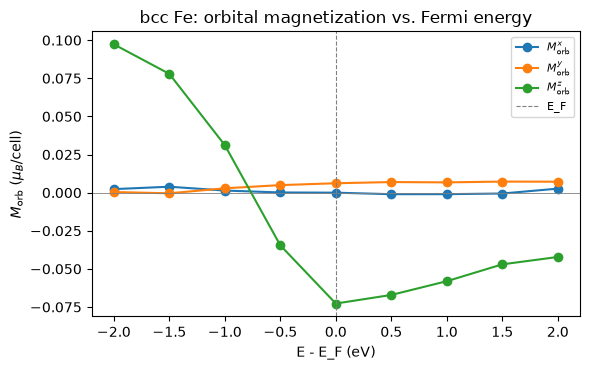

In [6]:
fermis = np.arange(E_FERMI - 2.0, E_FERMI + 2.01, 0.5)
scan = orbital_magnetization(result.hr, AA_R, BB_R, CC_R, RECIP, REAL,
                             fermi_energies=fermis * EV_TO_HARTREE, mesh=(20, 20, 20))

fig, ax = plt.subplots(figsize=(6, 3.8))
for i, label in enumerate('xyz'):
    ax.plot(fermis - E_FERMI, scan.m_orb[:, i], 'o-', label=f'$M_{{\\rm orb}}^{label}$')
ax.axvline(0.0, color='0.5', lw=0.8, ls='--', label='E_F')
ax.axhline(0.0, color='0.5', lw=0.6)
ax.set_xlabel('E - E_F (eV)'); ax.set_ylabel(r'$M_{\rm orb}$ ($\mu_B$/cell)')
ax.set_title('bcc Fe: orbital magnetization vs. Fermi energy')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Takeaway.** waw now implements postw90's full orbital-magnetization workflow -- the new `.uHu`-derived $BB(R)$/$CC(R)$ real-space quantities alongside the already-implemented $AA(R)$, and the $-2\mathrm{Im}[f]/[g]/[h]$ trace formulas (CTVR06/LVTS12) built on the SAME WYSV06 machinery notebook 18's AHC uses -- validated against real `wannier90.x`/`postw90.x` output, entirely waw-native.